In [1]:
# Add project root to Python path and change working directory
import sys
import os
import asyncio
from pathlib import Path

# Get project root
project_root = Path().absolute().parent.parent
sys.path.insert(0, str(project_root))

# Change working directory to project root so config.yaml can be found
os.chdir(project_root)

print(f"Added to path: {project_root}")

print(f"Working directory: {os.getcwd()}")


Added to path: c:\Users\J'sen\Desktop\GitHub\finance-rag
Working directory: c:\Users\J'sen\Desktop\GitHub\finance-rag


In [2]:
from src.utils.logger import get_logger
logger = get_logger(__name__)

## Load Test Sets and Evaluation Results
---

In [3]:
import json
default_test_path = "src/evaluation/data/test_set.json"
default_ablation_test_path = "src/evaluation/data/ablation_test_set.json"
default_output_path = "src/evaluation/data/eval_results.json"
default_ablation_output_path = "src/evaluation/data/ablation_results.json"

with open(default_test_path, "r", encoding="utf-8") as f:
    test_data = json.load(f)

with open(default_ablation_test_path, "r", encoding="utf-8") as f:
    ablation_test_data = json.load(f)
    
with open(default_output_path, "r", encoding="utf-8") as f:
    eval_result_data = json.load(f)

with open(default_ablation_output_path, "r", encoding="utf-8") as f:
    ablation_result_data = json.load(f)

print(len(test_data),len(ablation_test_data), len(eval_result_data), len(ablation_result_data))

50 20 21 20


In [4]:
def print_section(title, content):
    line = "=" * 60
    print(f"\n{line}")
    print(f"{title.center(60)}")
    print(f"{line}")
    print(content)

for i in ablation_result_data:
    print_section(
        "RAG ANSWER",
        i.get("rag_answer")
    )

    print_section(
        "LLM ONLY ANSWER",
        i.get("llm_only_answer")
    )

    print_section(
    "WEB SEARCH ANSWER",
    i.get("web_search_answer")
    )   



                         RAG ANSWER                         
Based on the provided sources, the total property and equipment, net and operating leases for Amazon in the U.S. as of December 31, 2024 was $241.6 billion [1 AMZN 10-K p.75].

This figure is explicitly stated in the consolidated balance sheet data showing:
- U.S. property and equipment, net and operating leases were $180.0 billion, $196.0 billion, and $241.6 billion as of December 31, 2022, 2023, and 2024 [1 AMZN 10-K p.75]

The $241.6 billion represents the combined total of:
- Property and equipment, net (which includes both owned assets and assets acquired under finance leases)
- Operating lease obligations for U.S. facilities

This is distinct from the consolidated total of $252.665 billion in property and equipment, net shown on the balance sheet [2 AMZN 10-K p.43], which represents only the owned and finance-leased assets without including operating lease obligations.

Sources:
[1 AMZN 10-K p.75 (AMZN_10-K_0001193125-

## Ablation Study Pipeline
---

In [5]:
from src.utils.prompts import LLM_AS_JUDGE_SYSTEM, LLM_AS_JUDGE_USER, LLM_AS_JUDGE_SYSTEM_NO_REF, LLM_AS_JUDGE_USER_NO_REF
from src.generation.llm import OpenRouterLLM
from config import load_config
config = load_config()

def llm_as_judge(input: List[Dict]) -> List[Dict]:

    judge_model_name = config["evaluation"].get("llm_as_judge_llm", None)
    if judge_model_name is None:
        logger.warning("Please define judge model name in config.yaml.")
        return []

    judge = OpenRouterLLM(model=judge_model_name)
    logger.info(f"Initializing LLM as Judge {judge_model_name}")

    results = []
    for i, item in enumerate(input):
        question = item["question"]
        ground_truth = item["ground_truth"]
        rag_answer = item["rag_answer"]
        llm_only_answer = item["llm_only_answer"]
        web_search_answer = item["web_search_answer"]

        # Evaluation with reference (ground truth)
        prompt = LLM_AS_JUDGE_USER.format(
            question=question,
            ground_truth=ground_truth,
            rag_answer=rag_answer,
            llm_only_answer=llm_only_answer,
            web_search_answer=web_search_answer
        )
        messages = [
            {"role": "system", "content": LLM_AS_JUDGE_SYSTEM},
            {"role": "user", "content": prompt}
        ]
        response_w_ref = judge.generate(messages)

        # Evaluation without reference
        no_ref_prompt = LLM_AS_JUDGE_USER_NO_REF.format(
            question=question,
            rag_answer=rag_answer,
            llm_only_answer=llm_only_answer,
            web_search_answer=web_search_answer
        )
        messages = [
            {"role": "system", "content": LLM_AS_JUDGE_SYSTEM_NO_REF},
            {"role": "user", "content": no_ref_prompt}
        ]
        response_no_ref = judge.generate(messages)

        results.append({
            "index": i,
            "question": question,
            "ground_truth": ground_truth,
            "rag_answer": rag_answer,
            "llm_only_answer": llm_only_answer,
            "web_search_answer": web_search_answer,
            "judge_response_with_ref": response_w_ref,
            "judge_response_no_ref": response_no_ref
        })

    return results

evaluating = False # Set this to true when evaluating

if evaluating:
    results = llm_as_judge(ablation_result_data)

    with open("src/evaluation/data/ablation_comparison_results.json", "w", newline="", encoding="utf-8") as f:
            json.dump(results, f, indent=4) 


c:\Users\J'sen\Desktop\GitHub\finance-rag\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


## Result Aggregation
---

In [6]:
overall_totals = {
    "judge_response_with_ref": {
        "answer_1": {"factual_accuracy": 0, "completeness": 0, "conciseness": 0, "total": 0},
        "answer_2": {"factual_accuracy": 0, "completeness": 0, "conciseness": 0, "total": 0},
        "answer_3": {"factual_accuracy": 0, "completeness": 0, "conciseness": 0, "total": 0}
    },
    "judge_response_no_ref": {
        "answer_1": {"factual_accuracy": 0, "completeness": 0, "conciseness": 0, "total": 0},
        "answer_2": {"factual_accuracy": 0, "completeness": 0, "conciseness": 0, "total": 0},
        "answer_3": {"factual_accuracy": 0, "completeness": 0, "conciseness": 0, "total": 0}
    }
}
with open("src/evaluation/data/ablation_comparison_results.json", "r", encoding="utf-8") as f:
    results = json.load(f)
    
for result in results:
    for key in ["judge_response_with_ref", "judge_response_no_ref"]:
        sample = result[key]
        if isinstance(sample, str):
            sample = sample.strip().removeprefix("```json").removesuffix("```").strip()
            sample = json.loads(sample)
        
        for model_answer in ["answer_1", "answer_2", "answer_3"]:
            scores = sample[model_answer]
            for metric in overall_totals[key][model_answer]:
                overall_totals[key][model_answer][metric] += scores[metric]

max_scores = {"factual_accuracy": 3, "completeness": 3, "conciseness": 1, "total": 7}
n = len(results)

model_labels = {"answer_1": "RAG", "answer_2": "LLM Only", "answer_3": "Web Search"}

print(f"\n{'='*50}")
print(f"Aggregated Scores Across {n} Results")
print(f"{'='*50}")

for key, models in overall_totals.items():
    print(f"\n  --- {key} ---")
    for model_answer, totals in models.items():
        print(f"\n    {model_labels[model_answer]}:")
        for metric, value in totals.items():
            max_possible = max_scores[metric] * n
            print(f"      {metric.replace('_', ' ').title():<20} : {value}/{max_possible}")


Aggregated Scores Across 20 Results

  --- judge_response_with_ref ---

    RAG:
      Factual Accuracy     : 51/60
      Completeness         : 56/60
      Conciseness          : 17/20
      Total                : 124/140

    LLM Only:
      Factual Accuracy     : 10/60
      Completeness         : 30/60
      Conciseness          : 19/20
      Total                : 59/140

    Web Search:
      Factual Accuracy     : 17/60
      Completeness         : 29/60
      Conciseness          : 20/20
      Total                : 66/140

  --- judge_response_no_ref ---

    RAG:
      Factual Accuracy     : 50/60
      Completeness         : 57/60
      Conciseness          : 20/20
      Total                : 127/140

    LLM Only:
      Factual Accuracy     : 26/60
      Completeness         : 44/60
      Conciseness          : 20/20
      Total                : 90/140

    Web Search:
      Factual Accuracy     : 26/60
      Completeness         : 36/60
      Conciseness          : 20/20

## Single Sample Visualization
---

In [7]:
sample_result = results[0]
print(sample_result["question"])
print(sample_result["judge_response_with_ref"])
print(sample_result["judge_response_no_ref"])

What was the total property and equipment, net and operating leases for Amazon in the U.S. as of December 31, 2024?
```json
{
  "answer_1": {
    "factual_accuracy": 3,
    "completeness": 3,
    "conciseness": 1,
    "total": 7,
    "reasoning": "Answer 1 correctly identifies $241.6 billion as the total property and equipment, net and operating leases for Amazon in the U.S. as of December 31, 2024, matching the reference context exactly and providing proper sourcing."
  },
  "answer_2": {
    "factual_accuracy": 0,
    "completeness": 1,
    "conciseness": 1,
    "total": 2,
    "reasoning": "Answer 2 provides incorrect figures ($171,776 million and $41,587 million) that don't match the reference context and incorrectly states that U.S. specific breakdown is not provided, when the reference clearly indicates it is available."
  },
  "answer_3": {
    "factual_accuracy": 1,
    "completeness": 1,
    "conciseness": 1,
    "total": 3,
    "reasoning": "Answer 3 provides the wrong figure

## Aggregated Data Visualization
---


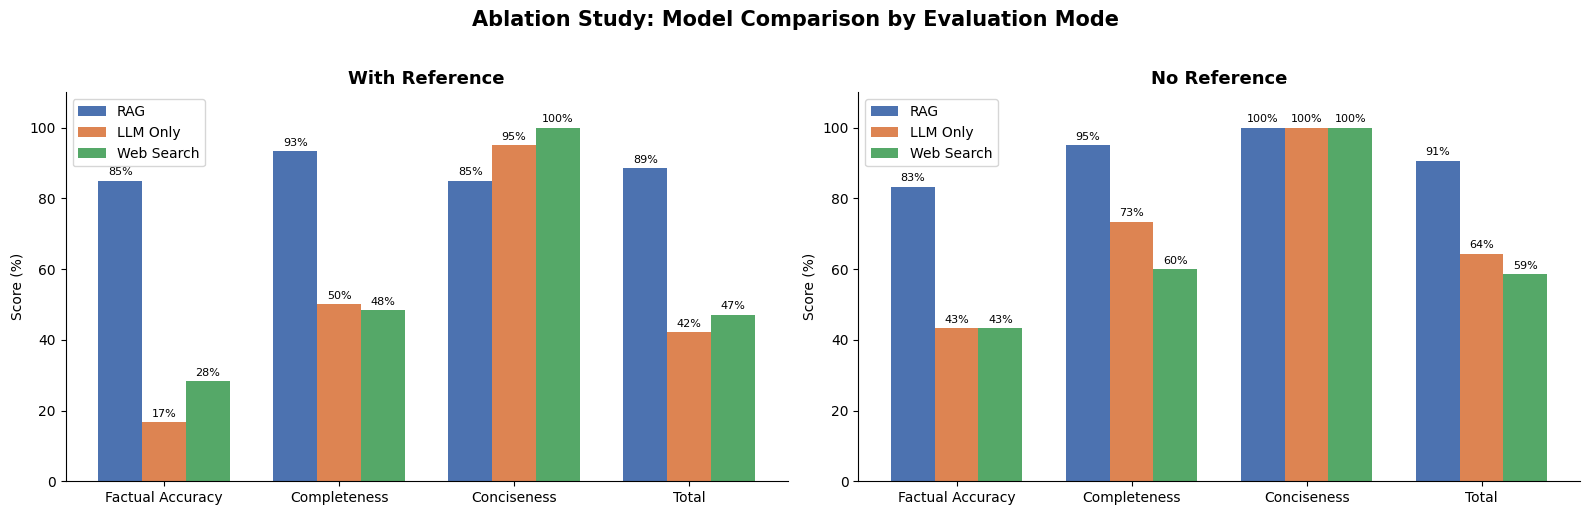

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model_labels = ["RAG", "LLM Only", "Web Search"]
metrics = ["factual_accuracy", "completeness", "conciseness", "total"]
metric_labels = ["Factual Accuracy", "Completeness", "Conciseness", "Total"]
max_scores = {"factual_accuracy": 3, "completeness": 3, "conciseness": 1, "total": 7}
n = 20

eval_modes = ["judge_response_with_ref", "judge_response_no_ref"]
eval_labels = ["With Reference", "No Reference"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ["#4C72B0", "#DD8452", "#55A868"]
x = np.arange(len(metrics))
width = 0.25

for ax, mode, label in zip(axes, eval_modes, eval_labels):
    for i, (model_key, model_label, color) in enumerate(zip(["answer_1", "answer_2", "answer_3"], model_labels, colors)):
        scores = overall_totals[mode][model_key]
        normalized = [scores[m] / (max_scores[m] * n) * 100 for m in metrics]
        bars = ax.bar(x + i * width, normalized, width, label=model_label, color=color)
        for bar, val in zip(bars, normalized):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f"{val:.0f}%", ha="center", va="bottom", fontsize=8)

    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xticks(x + width)
    ax.set_xticklabels(metric_labels)
    ax.set_ylabel("Score (%)")
    ax.set_ylim(0, 110)
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Ablation Study: Model Comparison by Evaluation Mode", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()